In [28]:
from ultralytics import YOLO
import torch.nn.functional as F

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
# 1. Load your newly distilled YOLOv8 student model
weights = "C:/Users/jordan.pierce/Documents/GitHub/CoralNet-Toolbox/data/Datasets/classify_tiny/results/yolo11n-test/weights/best.pt"
model = YOLO(weights)

In [100]:
image_path = "C:/Users/jordan.pierce/Documents/GitHub/CoralNet-Toolbox/data/Sample/D3/T_S04856.jpg"
original_height, original_width = Image.open(image_path).size

In [ ]:
captured_features = {}

# 1. Define a hook to intercept the spatial tensor
def hook_fn(module, input, output):
    # Safely grab the tensor, ignoring tuples
    captured_features['layer_9'] = output[0].detach() if isinstance(output, tuple) else output.detach()

# 2. Attach the hook to Layer 9 (the end of the backbone)
hook_handle = model.model.model[9].register_forward_hook(hook_fn)

# 3. Run a standard prediction
_ = model(image_path, verbose=False) 

# 4. Retrieve your spatial feature map
spatial_tensor = captured_features['layer_9']

# 5. Clean up
hook_handle.remove()

print(spatial_tensor.shape) 
# Expected Output: torch.Size([1, 256, H, W]) <--- This is what you need!

AttributeError: 'ClassificationModel' object has no attribute 'transforms'

In [95]:
results[0].shape

torch.Size([1, 84, 6300])

In [96]:
import torch
import torch.nn.functional as F

# Assume `spatial_tensor` is your output from Layer 8: Shape [1, C, H, W]
# Assume `img_height` and `img_width` are the dimensions of the UI image

# --- PRE-PROCESSING (Run once per image) ---

# 1. Upsample the feature map to match the image pixels perfectly
upsampled_features = F.interpolate(
    spatial_tensor, 
    size=(original_width, original_height), 
    mode='bilinear', 
    align_corners=False
) # Shape: [1, C, img_height, img_width]

# 2. L2 Normalize along the channel dimension (C)
# This makes cosine similarity extremely fast to compute later
normalized_features = F.normalize(upsampled_features, p=2, dim=1) 

# Drop the batch dimension since we are processing one image at a time
# Final shape ready for the UI: [C, img_height, img_width]
image_embeddings = normalized_features[0] 


# --- THE INTERACTIVE UI LOOP (Run every time the user clicks or drags the slider) ---

def get_similarity_mask(click_x, click_y, threshold=0.85):
    # 1. Extract the query vector at the user's click coordinate
    query_vector = image_embeddings[:, click_y, click_x] # Shape: [C]
    
    # 2. Reshape query vector for broadcasting: [C, 1, 1]
    query_vector = query_vector.view(-1, 1, 1)
    
    # 3. Compute Cosine Similarity
    # Since both are L2 normalized, a dot product (sum of element-wise multiplication) 
    # gives the exact cosine similarity score for every pixel simultaneously.
    similarity_map = torch.sum(image_embeddings * query_vector, dim=0) # Shape: [img_height, img_width]
    
    # 4. Apply the threshold to get the boolean mask
    mask = similarity_map > threshold
    
    # Return as a numpy array for standard UI libraries (OpenCV, PyQt, etc.)
    return mask.cpu().numpy()

In [97]:
mask = get_similarity_mask(1000, 800, 0.95)

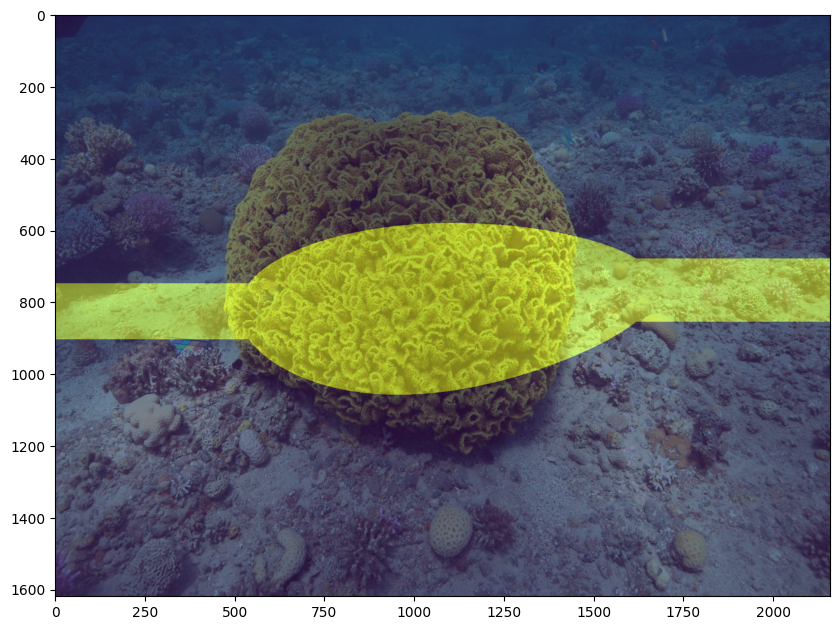

In [98]:
# Plot the original image with transparency
plt.figure(figsize=(10, 10))
plt.imshow(mask)
plt.imshow(plt.imread(image_path), alpha=0.5)
plt.show()